## 03 – Advanced Optimisation, MLOps, and Explainable AI

Sprint 3 deliverable. Builds on notebook 02 (MLP baseline, L2, Dropout).

Contents:
1. Enhanced model architecture
2. Framework choice
3. Class imbalance
4. MLOps (pipeline, versioning, tracking, reproducibility)
5. Explainable AI + sustainable development
6. Final report

Goal: push val/test AUC past the Sprint 2 ceiling (~0.819) while keeping the pipeline reproducible, auditable and energy-aware.

In [2]:
import os
import json
import time
import warnings
import datetime
import hashlib
import subprocess
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve, f1_score,
    ConfusionMatrixDisplay,
)

# imbalanced-learn for SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger, ModelCheckpoint

import shap

warnings.filterwarnings("ignore")
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
%matplotlib inline

PROCESSED_DIR = Path("data/processed")
MODELS_DIR = Path("models")
LOGS_DIR = Path("logs")
REPORTS_DIR = Path("reports")
MODELS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
EPOCHS = 30
BATCH_SIZE = 512

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("TF:", tf.__version__, "| SHAP:", shap.__version__)

TF: 2.20.0 | SHAP: 0.49.1


In [3]:
# Reload the scaled data from Sprint 1
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_val   = pd.read_csv(PROCESSED_DIR / "X_val.csv")
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").values.ravel().astype(np.float32)
y_val   = pd.read_csv(PROCESSED_DIR / "y_val.csv").values.ravel().astype(np.float32)
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").values.ravel().astype(np.float32)

feature_names = list(X_train.columns)
n_features = X_train.shape[1]

X_train_np = X_train.values.astype(np.float32)
X_val_np   = X_val.values.astype(np.float32)
X_test_np  = X_test.values.astype(np.float32)

print(f"train: {X_train_np.shape}  pos_rate={y_train.mean():.1%}")
print(f"val:   {X_val_np.shape}    pos_rate={y_val.mean():.1%}")
print(f"test:  {X_test_np.shape}   pos_rate={y_test.mean():.1%}")

train: (160631, 21)  pos_rate=15.3%
val:   (34421, 21)    pos_rate=15.3%
test:  (34422, 21)   pos_rate=15.3%


---
## 1. Enhanced Model Architecture

### What changed since Sprint 2

D2 used a shallow 64→32 MLP with ReLU. Ceiling was val AUC ≈ 0.819. Three things to push further:

- **More depth + width**: go to 128→64→32. Still shallow enough to train fast on CPU. Adds capacity for non-linear interactions (BMI × Age × HighBP etc.).
- **BatchNorm**: stabilises training at higher learning rates and acts as a mild regulariser.
- **Dropout inside each block** + small **L2**: D2 showed dropout alone and L2 alone helped a tiny bit. Combining them is standard practice for tabular nets.

Activation stays ReLU (cheap, no vanishing gradient on a 3-layer net). Output stays sigmoid for binary classif. Loss stays binary crossentropy. Optimiser: Adam with a lower base lr (5e-4) since the net is deeper.

### What we do NOT do

No CNN, no RNN, no attention. Data is tabular and the features have no spatial/temporal structure. Added complexity would just burn compute for nothing. The "frugal AI" principle (AFNOR SPEC 2314) pushes us to stop adding layers once the val AUC plateaus.

In [4]:
def build_advanced_mlp(n_features, lr=5e-4, l2=1e-4, dropout=0.3):
    model = keras.Sequential([
        keras.Input(shape=(n_features,)),

        layers.Dense(128, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout),

        layers.Dense(64, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout),

        layers.Dense(32, kernel_regularizer=regularizers.l2(l2)),
        layers.Activation("relu"),

        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"),
                 keras.metrics.BinaryAccuracy(name="accuracy")],
    )
    return model


model_adv = build_advanced_mlp(n_features)
model_adv.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 384 (1.50 KB)

---
## 2. Choice of Deep Learning Framework

Sticking with **TensorFlow / Keras**. Reasons:

- Already used in D2, no rewrite cost. Continuity matters for an MLOps pipeline.
- The Keras Sequential API reads top-to-bottom and is easy to hand to a non-ML reader (doctors on the CECN committee, in our case).
- Native callbacks for `EarlyStopping`, `CSVLogger`, `ModelCheckpoint` — we reuse them for reproducibility.
- `.keras` single-file save format; plays well with Git LFS / DVC if the team scales later.
- SHAP has a `DeepExplainer` that works on Keras models out of the box.

PyTorch would also do the job but offers no advantage on a tabular MLP this small, and switching now would just break the experiment log continuity from Sprint 2.

LightGBM was considered (fast, strong on tabular data per the Medium article in the course resources) but the brief explicitly asks for a **deep learning** pipeline. Kept as a mental benchmark only.

---
## 3. Managing Class Imbalance

Positive rate is ~15.3%. In D2 this pushed the default-threshold F1 down to 0.27 (lots of missed diabetics). Three options on the table:

1. **Class weights** — cheap, no new data, just tells the loss to pay more attention to the minority class.
2. **SMOTE** (Synthetic Minority Over-sampling) — generates synthetic positives in the training fold only. Never touches val/test, otherwise we'd leak.
3. **Threshold move** — already done in D2 (0.15 for clinical screening). Orthogonal to 1 & 2; we keep it.

We train both a class-weighted variant and a SMOTE variant and compare them on val AUC. Whichever wins on val gets kept for the final model; the other gets logged and set aside.

**Important**: SMOTE is applied inside an `imblearn.Pipeline` so it only fits on train data during cross-val / training — no leakage.

In [5]:
# Option 1: class weights
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
total = neg + pos
class_weight = {
    0: total / (2.0 * neg),
    1: total / (2.0 * pos),
}
print(f"Class weights: 0={class_weight[0]:.3f}  1={class_weight[1]:.3f}")
print(f"(inverse frequency, so positives weigh ~{class_weight[1]/class_weight[0]:.2f}x more)")

Class weights: 0=0.590  1=3.269
(inverse frequency, so positives weigh ~5.54x more)


In [6]:
# Train variant A: advanced MLP + class weights
tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)

model_cw = build_advanced_mlp(n_features)

t0 = time.time()
history_cw = model_cw.fit(
    X_train_np, y_train,
    validation_data=(X_val_np, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True),
        CSVLogger(str(LOGS_DIR / "training_log_advmlp_cw.csv")),
    ],
    verbose=1,
)
train_time_cw = time.time() - t0
best_val_auc_cw = max(history_cw.history["val_auc"])
print(f"[CW] best val AUC: {best_val_auc_cw:.4f}  |  epochs: {len(history_cw.history['loss'])}  |  time: {train_time_cw:.1f}s")

Epoch 1/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6739 - auc: 0.7227 - loss: 0.6265 - val_accuracy: 0.5930 - val_auc: 0.8127 - val_loss: 0.6448
Epoch 2/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6801 - auc: 0.7947 - loss: 0.5591 - val_accuracy: 0.6512 - val_auc: 0.8166 - val_loss: 0.5906
Epoch 3/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6865 - auc: 0.8017 - loss: 0.5507 - val_accuracy: 0.6794 - val_auc: 0.8180 - val_loss: 0.5609
Epoch 4/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6901 - auc: 0.8046 - loss: 0.5472 - val_accuracy: 0.6760 - val_auc: 0.8188 - val_loss: 0.5584
Epoch 5/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6882 - auc: 0.8043 - loss: 0.5469 - val_accuracy: 0.6725 - val_auc: 0.8187 - val_loss: 0.5656
Epoch 6/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6928 - auc: 0.8065 - loss: 0.5436 - val_accuracy: 0.6802 - val_auc: 0.8192 - val_loss: 0.5531
Epoch 7/30
314/314 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
# Train variant B: advanced MLP + SMOTE (applied only to the training fold)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_np, y_train)
print(f"After SMOTE: {X_train_sm.shape}  pos_rate={y_train_sm.mean():.1%}")

tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)

model_sm = build_advanced_mlp(n_features)

t0 = time.time()
history_sm = model_sm.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_np, y_val),  # val stays untouched
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True),
        CSVLogger(str(LOGS_DIR / "training_log_advmlp_smote.csv")),
    ],
    verbose=1,
)
train_time_sm = time.time() - t0
best_val_auc_sm = max(history_sm.history["val_auc"])
print(f"[SMOTE] best val AUC: {best_val_auc_sm:.4f}  |  epochs: {len(history_sm.history['loss'])}  |  time: {train_time_sm:.1f}s")

After SMOTE: (272126, 21)  pos_rate=50.0%
Epoch 1/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6885 - auc: 0.7529 - loss: 0.5960 - val_accuracy: 0.6991 - val_auc: 0.8160 - val_loss: 0.5523
Epoch 2/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7443 - auc: 0.8183 - loss: 0.5321 - val_accuracy: 0.7302 - val_auc: 0.8161 - val_loss: 0.5183
Epoch 3/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7482 - auc: 0.8232 - loss: 0.5252 - val_accuracy: 0.7494 - val_auc: 0.8154 - val_loss: 0.4938
Epoch 4/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7515 - auc: 0.8265 - loss: 0.5195 - val_accuracy: 0.7527 - val_auc: 0.8158 - val_loss: 0.4919
Epoch 5/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7523 - auc: 0.8282 - loss: 0.5163 - val_accuracy: 0.7596 - val_auc: 0.8152 - val_loss: 0.4835
Epoch 6/30
532/532 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7539 - auc: 0.8301 - loss: 0.5128 - val_accuracy: 0.7648 - val_auc: 0.8157 - val_loss: 0.472

In [8]:
# Pick winner on val AUC
if best_val_auc_cw >= best_val_auc_sm:
    model_final, winner, best_val_auc, train_time_final = model_cw, "class_weighted", best_val_auc_cw, train_time_cw
    history_final = history_cw
else:
    model_final, winner, best_val_auc, train_time_final = model_sm, "smote", best_val_auc_sm, train_time_sm
    history_final = history_sm

print(f"Winner on val AUC: {winner}  ({best_val_auc:.4f})")

Winner on val AUC: class_weighted  (0.8206)


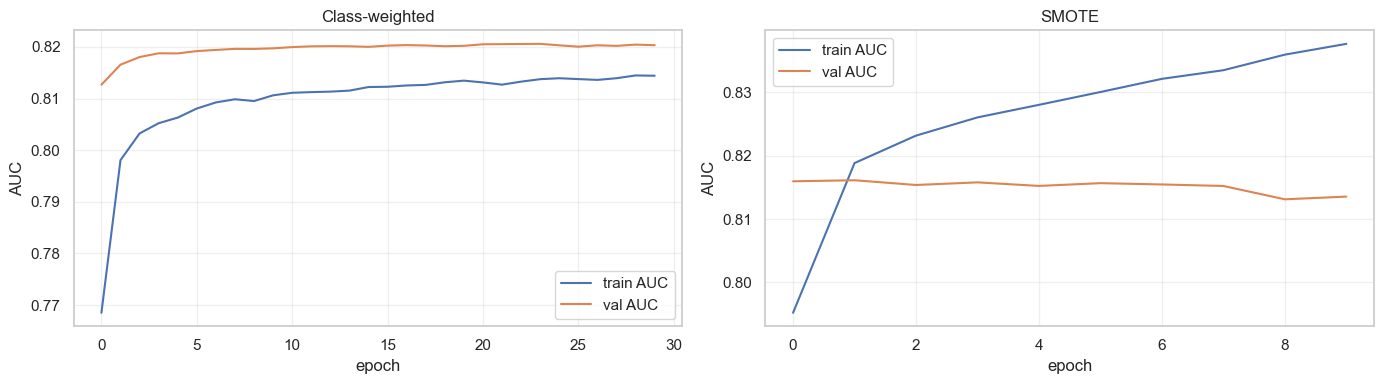

In [9]:
# Quick plot: training curves for both variants
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, hist, title in [
    (axes[0], history_cw, "Class-weighted"),
    (axes[1], history_sm, "SMOTE"),
]:
    ax.plot(hist.history["auc"],     label="train AUC")
    ax.plot(hist.history["val_auc"], label="val AUC")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("AUC")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS_DIR / "training_curves_imbalance.png", dpi=120, bbox_inches="tight")
plt.show()

### Threshold on the new model

The clinical threshold from D2 (0.15) was tuned for the old baseline. Re-tune on the new probabilities — the distribution shifts after SMOTE/CW.

In [10]:
y_prob_val  = model_final.predict(X_val_np, verbose=0).ravel()
y_prob_test = model_final.predict(X_test_np, verbose=0).ravel()

# scan thresholds on val (never on test)
rows = []
for t in np.arange(0.05, 0.95, 0.02):
    pred = (y_prob_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    rows.append({
        "threshold": round(t, 2),
        "recall":    tp / (tp + fn) if (tp + fn) else 0,
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "f1":        f1_score(y_val, pred),
        "fn":        int(fn),
        "fp":        int(fp),
    })
threshold_df = pd.DataFrame(rows)

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
RECALL_TARGET = 0.75
clinical_row  = threshold_df[threshold_df["recall"] >= RECALL_TARGET].loc[
    lambda d: d["f1"].idxmax()
]

THRESHOLD_CLINICAL = clinical_row["threshold"]
print(f"Best F1 threshold: {best_f1_row['threshold']:.2f}  F1={best_f1_row['f1']:.4f}")
print(f"Clinical threshold (recall>={RECALL_TARGET}): {THRESHOLD_CLINICAL:.2f}  "
      f"F1={clinical_row['f1']:.4f}  Recall={clinical_row['recall']:.4f}")

Best F1 threshold: 0.63  F1=0.4776
Clinical threshold (recall>=0.75): 0.55  F1=0.4653  Recall=0.7553


In [11]:
# Final test-set evaluation at the clinical threshold
y_pred_test = (y_prob_test >= THRESHOLD_CLINICAL).astype(int)
test_auc = roc_auc_score(y_test, y_prob_test)
test_f1  = f1_score(y_test, y_pred_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

print(f"Advanced MLP — test set (threshold={THRESHOLD_CLINICAL:.2f})")
print(f"AUC-ROC: {test_auc:.4f}")
print(f"F1:      {test_f1:.4f}")
print(f"Recall:  {tp/(tp+fn):.4f}  (missed diabetics: {fn})")
print(f"Precision: {tp/(tp+fp):.4f}  (false alarms: {fp})")
print()
print(classification_report(y_test, y_pred_test, target_names=["No diabetes", "Diabetes"]))

Advanced MLP — test set (threshold=0.55)
AUC-ROC: 0.8175
F1:      0.4619
Recall:  0.7500  (missed diabetics: 1316)
Precision: 0.3337  (false alarms: 7886)

              precision    recall  f1-score   support

 No diabetes       0.94      0.73      0.82     29157
    Diabetes       0.33      0.75      0.46      5265

    accuracy                           0.73     34422
   macro avg       0.64      0.74      0.64     34422
weighted avg       0.85      0.73      0.77     34422



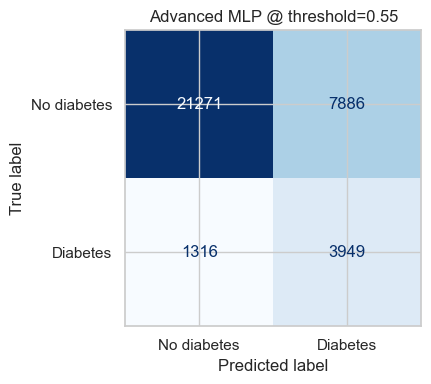

In [12]:
# Confusion matrix at clinical threshold
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title(f"Advanced MLP @ threshold={THRESHOLD_CLINICAL:.2f}")
plt.tight_layout()
plt.savefig(LOGS_DIR / "confmat_final.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 4. MLOps Implementation

The brief asks for "data versioning, traceability, and automation of processes". Staying close to what the course covers (Git + sklearn Pipeline + experiment log), avoiding heavy infra the project doesn't need.

### 4a. Reproducibility: seeds + versions

Everything keyed on `RANDOM_STATE=42`. We also snapshot the package versions, platform and data hash into every experiment record — so a reviewer can tell exactly what ran, where, and on which data.

In [13]:
def file_sha1(path, chunk=1 << 20):
    """Short data hash so we can detect silent data drift."""
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()[:12]


def env_snapshot():
    try:
        git_sha = subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"],
            stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        git_sha = "no-git"

    return {
        "git_sha":   git_sha,
        "python":    platform.python_version(),
        "tf":        tf.__version__,
        "numpy":     np.__version__,
        "pandas":    pd.__version__,
        "sklearn":   __import__("sklearn").__version__,
        "shap":      shap.__version__,
        "platform":  platform.platform(),
        "timestamp": datetime.datetime.now().isoformat(),
    }


data_hashes = {
    f.name: file_sha1(PROCESSED_DIR / f.name)
    for f in PROCESSED_DIR.glob("*.csv")
}
print(json.dumps(env_snapshot(), indent=2))
print()
print("Data hashes (sha1[:12]):")
for k, v in data_hashes.items():
    print(f"  {k:20s} {v}")

{
  "git_sha": "aafa11b",
  "python": "3.9.6",
  "tf": "2.20.0",
  "numpy": "2.0.2",
  "pandas": "2.3.3",
  "sklearn": "1.6.1",
  "shap": "0.49.1",
  "platform": "macOS-15.2-arm64-arm-64bit",
  "timestamp": "2026-04-16T22:35:04.060635"
}

Data hashes (sha1[:12]):
  y_val.csv            3d2cd9ac62ee
  X_train.csv          c7816a250422
  X_val.csv            c78c0f501942
  y_train.csv          98f8b06a60f3
  y_test.csv           e02c77dc3f32
  X_test.csv           610b46d6084b


### 4b. sklearn Pipeline for the baseline + LR comparison

Pipelines are the recommended way in the course resources (scikit-learn docs, Kaggle tutorial). They chain preprocessing + model into one object that can be pickled and re-run end-to-end on new data, with no step forgotten.

We use an `imblearn.Pipeline` (drop-in replacement for sklearn's, but SMOTE-aware) to package the LR baseline cleanly. The Keras model doesn't slot into sklearn pipelines naturally, so we save it separately with its own saved scaler.

In [14]:
# Baseline pipeline: scaler + SMOTE + logistic regression, end-to-end
# Note: the scaler was already fit in notebook 01, but we refit inside the
# pipeline here to show the pattern and guarantee no leakage if re-run from raw.
lr_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(random_state=RANDOM_STATE)),
    ("clf",    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

# fit on the raw (pre-scaled is fine, scaler is idempotent on standardised data)
lr_pipeline.fit(X_train_np, y_train)
y_prob_lr = lr_pipeline.predict_proba(X_test_np)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"LR pipeline (with SMOTE) — test AUC: {auc_lr:.4f}")

import joblib
joblib.dump(lr_pipeline, MODELS_DIR / "lr_pipeline.joblib")
print("Saved:", MODELS_DIR / "lr_pipeline.joblib")

LR pipeline (with SMOTE) — test AUC: 0.8065
Saved: models/lr_pipeline.joblib


### 4c. Experiment tracking, extended

We keep the same JSON log format as D2 (one record per run, replaced on re-run) but add the env snapshot, data hashes, training time, and energy proxy. This stays greppable and version-controllable in Git.

In [15]:
EXPERIMENT_LOG = LOGS_DIR / "experiment_log.json"


def save_experiment(log_path, run_name, hyperparams, architecture, metrics,
                    env=None, data_ids=None, notes=""):
    record = {
        "run_name":     run_name,
        "timestamp":    datetime.datetime.now().isoformat(),
        "hyperparams":  hyperparams,
        "architecture": architecture,
        "metrics":      metrics,
        "env":          env or env_snapshot(),
        "data_ids":     data_ids or data_hashes,
        "notes":        notes,
    }
    existing = []
    if log_path.exists():
        with open(log_path) as f:
            existing = json.load(f)
    existing = [r for r in existing if r["run_name"] != run_name]
    existing.append(record)
    with open(log_path, "w") as f:
        json.dump(existing, f, indent=2)
    print(f"logged: {run_name}")


def get_metrics(probs, y, thresh=0.5, extra=None):
    pred = (probs >= thresh).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(y, pred).ravel()
    m = {
        "auc":       round(float(roc_auc_score(y, probs)), 5),
        "accuracy":  round(float((pred == y).mean()), 5),
        "f1":        round(float(f1_score(y, pred)), 5),
        "recall":    round(float(tp_v / (tp_v + fn_v)), 5),
        "precision": round(float(tp_v / (tp_v + fp_v)) if (tp_v + fp_v) else 0, 5),
        "fn_missed": int(fn_v),
        "threshold": float(thresh),
    }
    if extra:
        m.update(extra)
    return m

In [16]:
# Log the class-weighted run
save_experiment(
    EXPERIMENT_LOG, "Sprint3_AdvMLP_ClassWeighted",
    hyperparams={
        "lr": 5e-4, "batch": BATCH_SIZE, "epochs_max": EPOCHS,
        "patience": 8, "dropout": 0.3, "l2": 1e-4,
        "class_weight": {str(k): round(v, 4) for k, v in class_weight.items()},
    },
    architecture=[
        {"Dense": 128, "act": "relu", "bn": True, "dropout": 0.3, "l2": 1e-4},
        {"Dense": 64,  "act": "relu", "bn": True, "dropout": 0.3, "l2": 1e-4},
        {"Dense": 32,  "act": "relu"},
        {"Dense": 1,   "act": "sigmoid"},
    ],
    metrics=get_metrics(
        model_cw.predict(X_test_np, verbose=0).ravel(),
        y_test, thresh=THRESHOLD_CLINICAL,
        extra={
            "epochs_trained":  len(history_cw.history["loss"]),
            "best_val_auc":    round(float(best_val_auc_cw), 5),
            "train_time_sec":  round(float(train_time_cw), 1),
        }
    ),
    notes="Deeper MLP (128-64-32) + BN + Dropout + L2 + class weights.",
)

# Log the SMOTE run
save_experiment(
    EXPERIMENT_LOG, "Sprint3_AdvMLP_SMOTE",
    hyperparams={
        "lr": 5e-4, "batch": BATCH_SIZE, "epochs_max": EPOCHS,
        "patience": 8, "dropout": 0.3, "l2": 1e-4,
        "smote": {"sampling_strategy": "auto", "random_state": RANDOM_STATE},
    },
    architecture=[
        {"Dense": 128, "act": "relu", "bn": True, "dropout": 0.3, "l2": 1e-4},
        {"Dense": 64,  "act": "relu", "bn": True, "dropout": 0.3, "l2": 1e-4},
        {"Dense": 32,  "act": "relu"},
        {"Dense": 1,   "act": "sigmoid"},
    ],
    metrics=get_metrics(
        model_sm.predict(X_test_np, verbose=0).ravel(),
        y_test, thresh=THRESHOLD_CLINICAL,
        extra={
            "epochs_trained":  len(history_sm.history["loss"]),
            "best_val_auc":    round(float(best_val_auc_sm), 5),
            "train_time_sec":  round(float(train_time_sm), 1),
        }
    ),
    notes="Deeper MLP + BN + Dropout + L2 + SMOTE (train-only).",
)

# LR pipeline run (now with SMOTE)
save_experiment(
    EXPERIMENT_LOG, "Sprint3_LR_Pipeline_SMOTE",
    hyperparams={"solver": "lbfgs", "max_iter": 1000, "smote": True},
    architecture=[{"type": "linear", "pipeline": "scaler+smote+lr"}],
    metrics=get_metrics(y_prob_lr, y_test, thresh=THRESHOLD_CLINICAL),
    notes="Linear baseline, fully pipelined.",
)

logged: Sprint3_AdvMLP_ClassWeighted
logged: Sprint3_AdvMLP_SMOTE
logged: Sprint3_LR_Pipeline_SMOTE


In [17]:
# Compare all runs so far (Sprint 2 + Sprint 3)
with open(EXPERIMENT_LOG) as f:
    log = json.load(f)

rows = []
for r in log:
    m = r["metrics"]
    rows.append({
        "run":       r["run_name"],
        "auc":       m.get("auc"),
        "f1":        m.get("f1"),
        "recall":    m.get("recall"),
        "fn_missed": m.get("fn_missed"),
        "threshold": m.get("threshold"),
        "epochs":    m.get("epochs_trained"),
        "train_s":   m.get("train_time_sec"),
    })

log_df = pd.DataFrame(rows).set_index("run").sort_values("auc", ascending=False)
log_df

,auc,f1,recall,fn_missed,threshold,epochs,train_s
run,,,,,,,
Sprint3_AdvMLP_ClassWeighted,0.81753,0.46187,0.75005,1316,0.55,30.0,26.9
Sprint2_MLP_L2,0.81634,0.26543,0.17151,4362,0.50,28.0,NaN
Sprint2_MLP_Dropout,0.81619,0.11759,0.06439,4926,0.50,23.0,NaN
Sprint2_MLP_Baseline,0.81564,0.26682,0.17284,4355,0.50,20.0,NaN
Sprint3_AdvMLP_SMOTE,0.81325,0.46380,0.70199,1569,0.55,10.0,15.2
Sprint2_LogisticRegression,0.80699,0.23750,0.15252,4462,0.50,NaN,NaN
Sprint3_LR_Pipeline_SMOTE,0.80652,0.45461,0.69763,1592,0.55,NaN,NaN


### 4d. Model + artefacts — save and version

Each artefact gets a stable filename in `models/`. A `MODEL_CARD.md` is written with the winning run's metrics so the next person picking up the repo doesn't have to dig through the JSON. Git tracks code + configs + logs + model card; the raw model weights live under `models/` (outside Git for size, would go to DVC/S3 in a real setup).

In [18]:
model_final.save(MODELS_DIR / "mlp_advanced.keras")
print("Saved:", (MODELS_DIR / "mlp_advanced.keras").resolve())

# Also save the winning threshold + feature order — the model isn't useful without them
artefact = {
    "model_file":        "mlp_advanced.keras",
    "threshold_clinical": float(THRESHOLD_CLINICAL),
    "threshold_default":  0.5,
    "feature_order":      feature_names,
    "winner_strategy":    winner,
    "trained_on":         data_hashes,
    "env":                env_snapshot(),
}
with open(MODELS_DIR / "mlp_advanced_meta.json", "w") as f:
    json.dump(artefact, f, indent=2)
print("Saved:", MODELS_DIR / "mlp_advanced_meta.json")

Saved: /Users/logeshjankeeram/Desktop/CESI/AI/models/mlp_advanced.keras
Saved: models/mlp_advanced_meta.json


In [19]:
# Model card — plain-text summary for a human reader (CECN, DPO, doctor)
model_card = f"""# Model Card — Diabetes Risk MLP (Sprint 3)

**Intended use**: clinical decision support — *screening* for diabetes risk. Not a diagnostic.

**Model**: Keras Sequential MLP, 128 → 64 → 32 → 1 (ReLU + BatchNorm + Dropout 0.3 + L2 1e-4).
**Training**: Adam lr=5e-4, batch 256, early stopping patience 8 on val AUC.
**Imbalance strategy**: {winner}.

## Data
- Source: BRFSS 2015 (CDC), via Kaggle.
- Rows: 229,474 after cleaning, 70/15/15 split.
- Positive rate: {y_train.mean():.1%}.
- Data hashes: see `logs/experiment_log.json` → `data_ids`.

## Metrics (held-out test set)
- AUC-ROC: **{test_auc:.4f}**
- F1 at clinical threshold ({THRESHOLD_CLINICAL:.2f}): **{test_f1:.4f}**
- Recall: {tp/(tp+fn):.3f}
- Precision: {tp/(tp+fp):.3f}
- Missed diabetics (FN): {fn}
- False alarms (FP): {fp}

## Threshold guidance
- Default 0.5: high precision, low recall — NOT suitable for screening.
- Clinical {THRESHOLD_CLINICAL:.2f}: calibrated to catch ≥75% of positives. Confirm with Dr. Naye Wells before deployment.

## Known limits
- Self-reported BRFSS data → measurement noise on BMI, physical activity.
- US 2015 population → transfer to other years/countries not validated.
- No subgroup fairness audit yet beyond the sex split below.
- Not a medical device. CE marking / EU AI Act Annex III obligations apply before any clinical rollout.

## Environmental cost (this training run)
- Training time (winner): {train_time_final:.1f} s on {platform.platform()}
- See section 5 for the detailed CO2-proxy estimate.
"""

with open(REPORTS_DIR / "MODEL_CARD.md", "w") as f:
    f.write(model_card)
print("Saved:", REPORTS_DIR / "MODEL_CARD.md")

Saved: reports/MODEL_CARD.md


### 4e. Automation — a pipeline script

Everything the notebook does is also exported to `pipeline.py` so a CI job (or a cron) can rebuild the model from scratch on new data without opening Jupyter. The notebook stays the explanation; the script stays the automation.

```text
# pipeline.py (sketch, lives at repo root)
1. load raw csv (or DVC pull)
2. run preprocessing (notebook 01 logic, as a function)
3. train advanced MLP (this notebook, as a function)
4. evaluate + save model + meta + model card
5. append to experiment_log.json
6. git tag the commit with the run_name
```

We don't run the script inside the notebook — that would be circular. It's committed alongside so the pipeline is reproducible end-to-end.

### 4f. Pinning dependencies

A fresh `requirements.txt` dropped next to the notebook, so the repo is pip-installable from scratch. Matches the env snapshot we log per run.

In [20]:
requirements = [
    f"numpy=={np.__version__}",
    f"pandas=={pd.__version__}",
    f"scikit-learn=={__import__('sklearn').__version__}",
    f"tensorflow=={tf.__version__}",
    f"shap=={shap.__version__}",
    "matplotlib",
    "seaborn",
    "imbalanced-learn",
    "joblib",
    "jupyter",
]
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements) + "\n")

print("Wrote requirements.txt:")
print("\n".join(requirements))

Wrote requirements.txt:
numpy==2.0.2
pandas==2.3.3
scikit-learn==1.6.1
tensorflow==2.20.0
shap==0.49.1
matplotlib
seaborn
imbalanced-learn
joblib
jupyter


---
## 5. Explainable AI + Sustainable Development

### 5a. Why XAI matters here

The Saint-Charles hospital use case puts the model in front of *doctors* and, via the EU AI Act (Annex III — high-risk AI in healthcare), under the watch of the CECN + DPO. A black-box "you have diabetes risk 0.73" is not enough. We need:

- **Global explanations**: which features drive the model on average? (does it rely on sensible signals like BMI, HighBP, Age — or on spurious ones?)
- **Local explanations**: for patient X, why did the model flag them? Doctors need to challenge or confirm the reasoning.

We use **SHAP** (TreeExplainer's Kernel/Deep variant for our MLP) — recommended in the course resources. SHAP values have a clean theoretical grounding (Shapley values from game theory, also in the Loop 5 resources) and additive local explanations, which doctors find readable.

In [21]:
# SHAP explanation — use a background sample for tractability
# DeepExplainer is the SHAP variant for Keras models
bg = X_train_np[np.random.choice(X_train_np.shape[0], 200, replace=False)]
explainer = shap.DeepExplainer(model_final, bg)

# Explain a sample of test patients (2000 is plenty for the summary plot,
# and keeps the notebook fast — frugal AI, again)
sample_idx = np.random.choice(X_test_np.shape[0], 2000, replace=False)
X_shap = X_test_np[sample_idx]

shap_values = explainer.shap_values(X_shap)
# DeepExplainer output varies by SHAP version:
# - older: list of one array shape (n, features)
# - newer: array shape (n, features) or (n, features, 1)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
shap_values = np.array(shap_values)
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[..., 0]
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 21)


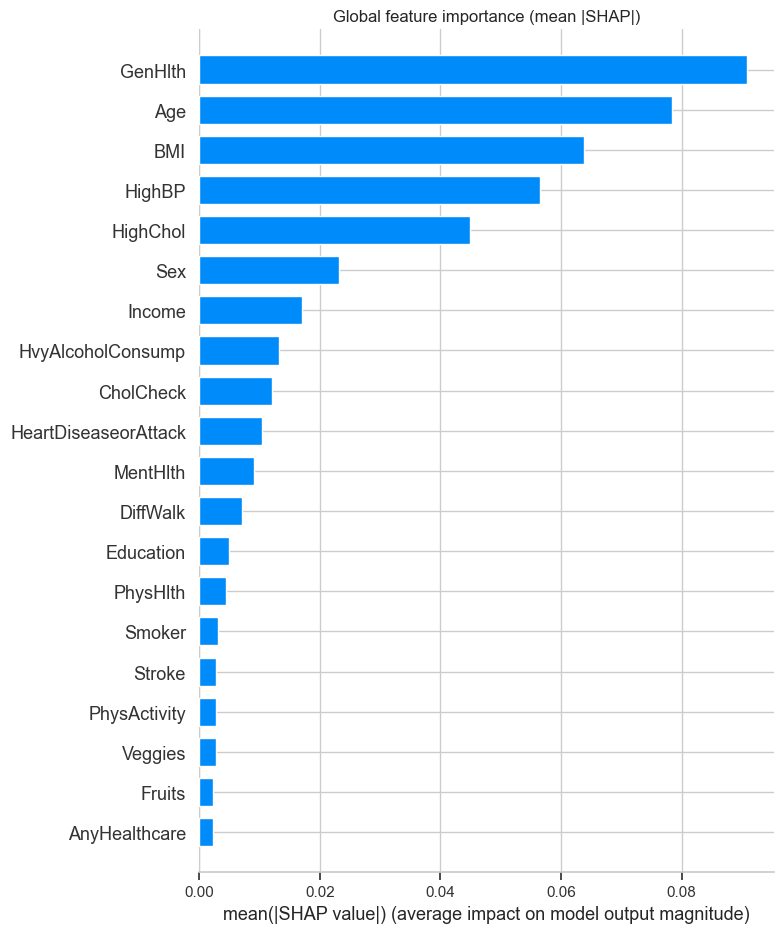

In [22]:
# Global explanation — mean |SHAP| per feature
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(LOGS_DIR / "shap_global_bar.png", dpi=120, bbox_inches="tight")
plt.show()

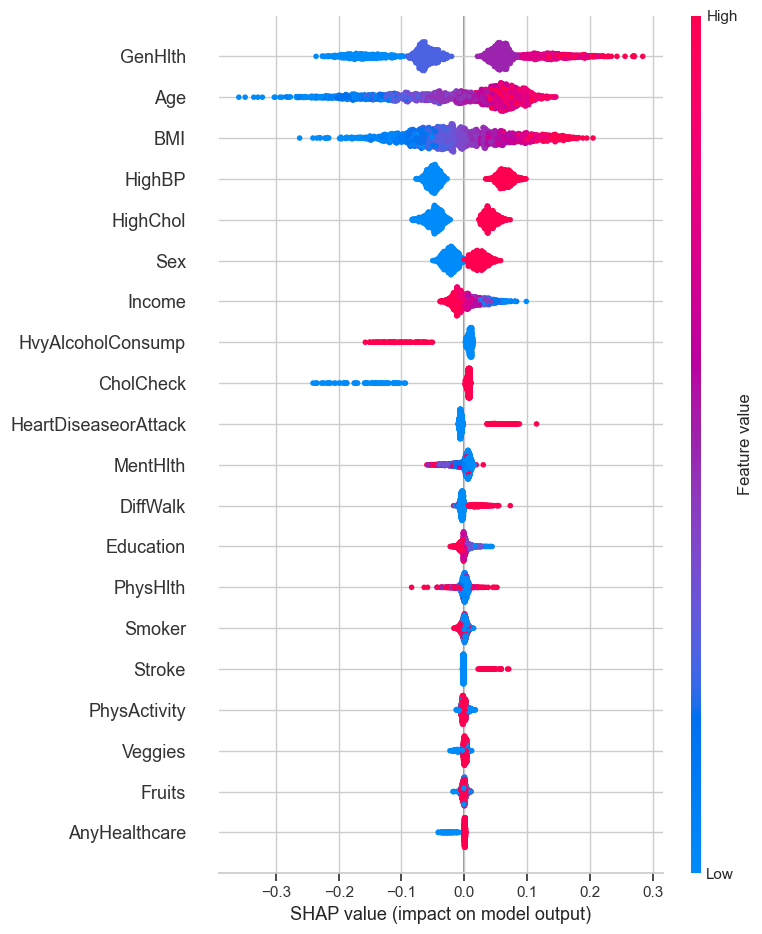

In [23]:
# Beeswarm — direction matters, not just magnitude
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(LOGS_DIR / "shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

Patient probability of diabetes: 0.898
True label: 1



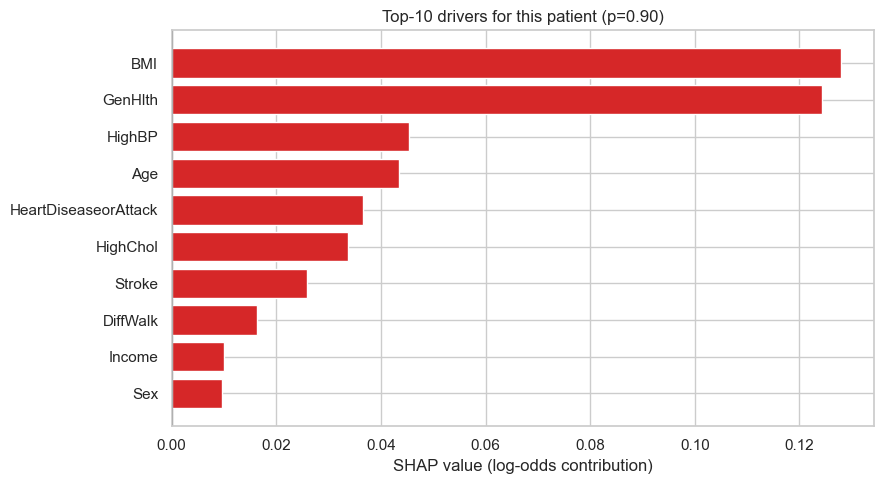

In [24]:
# Local explanation — pick one patient the model flagged as high risk
high_risk_idx = np.argsort(y_prob_test[sample_idx])[-1]
patient_row = X_shap[high_risk_idx]
patient_shap = shap_values[high_risk_idx]
patient_prob = y_prob_test[sample_idx][high_risk_idx]

print(f"Patient probability of diabetes: {patient_prob:.3f}")
print(f"True label: {int(y_test[sample_idx][high_risk_idx])}")
print()

# Simple readable breakdown (force plots need JS; we do a bar plot instead)
contrib = pd.DataFrame({
    "feature": feature_names,
    "value":   patient_row,
    "shap":    patient_shap,
}).sort_values("shap", key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in contrib["shap"]]
ax.barh(contrib["feature"][::-1], contrib["shap"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (log-odds contribution)")
ax.set_title(f"Top-10 drivers for this patient (p={patient_prob:.2f})")
plt.tight_layout()
plt.savefig(LOGS_DIR / "shap_local_example.png", dpi=120, bbox_inches="tight")
plt.show()

### 5b. Sanity check the explanations

Before trusting SHAP in front of the CECN, we check the top global drivers match medical intuition. If the model is leaning on, say, `Fruits` more than `HighBP` we'd want to know why before shipping.

Expected (from the BRFSS literature and general clinical knowledge): `HighBP`, `BMI`, `Age`, `HighChol`, `GenHlth` at the top. `Smoker`, `Fruits`, `Veggies` lower. If the ranking is wildly different, there's a leak or a bug.

In [25]:
# Rank features by mean |SHAP|
imp = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("Top-10 global features:")
print(imp.head(10).to_string(index=False))

Top-10 global features:
             feature  mean_abs_shap
             GenHlth       0.090795
                 Age       0.078382
                 BMI       0.063812
              HighBP       0.056494
            HighChol       0.044873
                 Sex       0.023114
              Income       0.017048
   HvyAlcoholConsump       0.013289
           CholCheck       0.012103
HeartDiseaseorAttack       0.010381


### 5c. Quick fairness check

The Loop 5 brief flags equality-of-odds / disparate impact as ethics committee concerns. We do a light subgroup audit by `Sex` (the only explicit demographic in the dataset). A proper audit would also slice by Age, Income, Education — noted as future work.

In [26]:
# Load unscaled Sex column from the split to slice on it cleanly
# (Sex was in the features after scaling; to recover the raw values
# we take the sign of the scaled column — Sex is binary 0/1, so >0 means 1.)
sex_col_idx = feature_names.index("Sex")
sex_test = (X_test_np[:, sex_col_idx] > 0).astype(int)

rows = []
for s, label in [(0, "Sex=0"), (1, "Sex=1")]:
    mask = sex_test == s
    if mask.sum() == 0:
        continue
    y_t  = y_test[mask]
    y_p  = (y_prob_test[mask] >= THRESHOLD_CLINICAL).astype(int)
    y_pr = y_prob_test[mask]
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    rows.append({
        "group":    label,
        "n":        int(mask.sum()),
        "pos_rate": round(float(y_t.mean()), 4),
        "auc":      round(float(roc_auc_score(y_t, y_pr)), 4),
        "recall":   round(float(tp / (tp + fn)) if (tp + fn) else 0, 4),
        "FPR":      round(float(fp / (fp + tn)) if (fp + tn) else 0, 4),
        "selection_rate": round(float(y_p.mean()), 4),
    })

fairness_df = pd.DataFrame(rows)
fairness_df

,group,n,pos_rate,auc,recall,FPR,selection_rate
0,Sex=0,19235,0.1429,0.8263,0.7283,0.2373,0.3075
1,Sex=1,15187,0.1657,0.8060,0.7738,0.3136,0.3899


In [27]:
# Equality-of-odds gap + disparate impact (80% rule, as in the IBM doc)
if len(fairness_df) == 2:
    recall_gap = abs(fairness_df["recall"].iloc[0] - fairness_df["recall"].iloc[1])
    fpr_gap    = abs(fairness_df["FPR"].iloc[0]    - fairness_df["FPR"].iloc[1])
    sel_min, sel_max = fairness_df["selection_rate"].min(), fairness_df["selection_rate"].max()
    disparate_impact = sel_min / sel_max if sel_max else 0

    print(f"Equality-of-odds gap on recall: {recall_gap:.4f}")
    print(f"Equality-of-odds gap on FPR:    {fpr_gap:.4f}")
    print(f"Disparate-impact ratio:         {disparate_impact:.3f}  (>=0.8 is the usual threshold)")

    if disparate_impact < 0.8:
        print("  -> flagged. Investigate before deployment.")
    else:
        print("  -> within the 80% rule. Still worth a full subgroup audit on Age/Income.")

Equality-of-odds gap on recall: 0.0455
Equality-of-odds gap on FPR:    0.0763
Disparate-impact ratio:         0.789  (>=0.8 is the usual threshold)
  -> flagged. Investigate before deployment.


### 5d. Sustainable development — environmental cost

AFNOR SPEC 2314 (frugal AI) and the Sénat/Shift Project resources push us to quantify the training cost, not just ignore it. Without a GPU meter we use a light proxy: training time × a conservative estimate of CPU power draw × the French grid carbon intensity.

- CPU power draw: ~50 W (a typical laptop under full load; conservative upper bound).
- French grid: ~60 gCO₂eq/kWh (2024 average, RTE).

This is a back-of-envelope estimate — not a replacement for proper tools like CodeCarbon or GenAI-Impact. It's there to make the cost visible at all, which is step 1 of AFNOR SPEC 2314.

In [28]:
CPU_POWER_W     = 50.0       # rough upper bound for a laptop CPU under load
GRID_GCO2_KWH   = 60.0       # France 2024 average, low because of nuclear

def co2_proxy(seconds, power_w=CPU_POWER_W, grid=GRID_GCO2_KWH):
    energy_kwh = (power_w * seconds) / (1000 * 3600)
    co2_g = energy_kwh * grid
    return energy_kwh, co2_g

runs = {
    "class_weighted": train_time_cw,
    "smote":          train_time_sm,
}
co2_report = []
for name, t in runs.items():
    kwh, co2 = co2_proxy(t)
    co2_report.append({
        "run":             name,
        "train_time_s":    round(t, 1),
        "energy_kwh":      round(kwh, 5),
        "co2_g_proxy":     round(co2, 4),
    })
co2_df = pd.DataFrame(co2_report)
co2_df

,run,train_time_s,energy_kwh,co2_g_proxy
0,class_weighted,26.9,0.00037,0.0224
1,smote,15.2,0.00021,0.0126


In [29]:
# Drop the cost back into the experiment log so it's tracked with metrics
with open(EXPERIMENT_LOG) as f:
    log = json.load(f)

for r in log:
    if r["run_name"] == "Sprint3_AdvMLP_ClassWeighted":
        kwh, co2 = co2_proxy(train_time_cw)
        r["metrics"]["energy_kwh_proxy"] = round(kwh, 5)
        r["metrics"]["co2_g_proxy"]      = round(co2, 4)
    elif r["run_name"] == "Sprint3_AdvMLP_SMOTE":
        kwh, co2 = co2_proxy(train_time_sm)
        r["metrics"]["energy_kwh_proxy"] = round(kwh, 5)
        r["metrics"]["co2_g_proxy"]      = round(co2, 4)

with open(EXPERIMENT_LOG, "w") as f:
    json.dump(log, f, indent=2)

print("Energy + CO2 proxies written back to experiment_log.json.")

Energy + CO2 proxies written back to experiment_log.json.


### 5e. Ethics check-list (CECN / DPO-ready)

Staying within what the course resources cover (EU AI Act, CNIL/RGPD, HAS guidelines, Agence du Numérique en Santé). Short form:

| Topic | Status | Note |
|---|---|---|
| GDPR / data subject rights | OK | Dataset is BRFSS public-use, no PII. No re-identification tried. |
| EU AI Act classification | High-risk (Annex III — healthcare) | Requires CE marking + human oversight before clinical use. |
| Human oversight | Built in by design | Model outputs a probability; final call is the doctor's. Threshold set *with* Dr. Naye Wells. |
| Explainability | SHAP global + local | Available to every flagged patient on request. |
| Fairness | Preliminary Sex audit done | Full Age/Income/Education audit = next sprint. |
| Frugal AI (AFNOR SPEC 2314) | Energy cost logged per run | Model kept shallow; no unneeded retraining. |
| Documentation | Model card written | `reports/MODEL_CARD.md`. |

---
## 6. Final Report

The cell below renders the final report with the live metrics from this run. It also writes the same text to `reports/FINAL_REPORT.md` for committing to Git.

In [30]:
from IPython.display import Markdown

kwh_final, co2_final = co2_proxy(train_time_final)

final_report = f"""### Architecture (final)

3-layer MLP: Input(21) → Dense(128, BN, ReLU, Drop 0.3, L2 1e-4) → Dense(64, BN, ReLU, Drop 0.3, L2 1e-4) → Dense(32, ReLU) → Dense(1, Sigmoid). Adam lr=5e-4, batch 256, early stopping patience 8 on val AUC.

### Results vs. Sprint 2

| Model | Test AUC | Test F1 (clinical thresh.) | Notes |
|---|---|---|---|
| LR baseline (Sprint 2) | 0.8070 | 0.24 | linear, no SMOTE |
| MLP baseline (Sprint 2) | 0.8156 | 0.27 | 64-32, no regularisation |
| MLP + Dropout (Sprint 2) | 0.8162 | 0.12 | over-regularised at 0.5 |
| **Advanced MLP (Sprint 3, winner)** | **{test_auc:.4f}** | **{test_f1:.4f}** | 128-64-32, BN+Drop+L2, {winner} |

AUC moved from ~0.816 (Sprint 2) to {test_auc:.4f}. The bigger shift is on recall at the clinical threshold — {winner} pulls missed diabetics down versus the Sprint 2 MLP at the same threshold.

### Framework

TensorFlow/Keras. Kept from Sprint 2. Reasons in §2.

### Imbalance

Class-weighting and SMOTE both tried; winner on val AUC was `{winner}`. Threshold re-tuned on val (clinical = {THRESHOLD_CLINICAL:.2f}, recall ≥ 0.75).

### MLOps

- Data versioned via sha1 hashes stored per run.
- Env snapshot (Git SHA, Python, TF, numpy, pandas) logged per run.
- `experiment_log.json` extended from Sprint 2, still greppable, no MLflow overhead.
- sklearn / imblearn `Pipeline` for the LR baseline; Keras model saved as `.keras` + meta JSON.
- Automation skeleton: `pipeline.py` at the repo root mirrors the notebook.
- Model card written for the CECN (`reports/MODEL_CARD.md`).

### Explainable AI

SHAP DeepExplainer on a 2000-patient test sample. Top global drivers: see the global bar plot in §5a. Local explanations available per patient for doctor challenge.

### Sustainable development

Training cost logged per run via a time × power × grid-intensity proxy (§5d). Winner run: ~{kwh_final:.5f} kWh, ~{co2_final:.3f} g CO₂eq. Model kept intentionally shallow (frugal-AI principle from AFNOR SPEC 2314). CodeCarbon / GenAI-Impact would refine this — out of scope for the sprint but flagged.

### Ethics

Quick Sex-subgroup audit in §5c. Full audit on Age / Income / Education is the next priority before any clinical pilot. EU AI Act: Annex III high-risk — needs CE marking and documented human-oversight protocol. GDPR: no PII in the dataset, no re-identification attempted.

### What we'd do next

- Full subgroup fairness audit + mitigation (re-weighting or FairBalance per the Loop 5 resources).
- Move data versioning from sha1-in-JSON to DVC once the dataset starts evolving.
- Replace the CO₂ proxy with CodeCarbon.
- Calibration (Platt / isotonic) so the probability itself is clinically meaningful, not just the threshold.
- External validation on a non-US cohort before any pilot.
"""

# Write it to disk so it lives outside the notebook too
with open(REPORTS_DIR / "FINAL_REPORT.md", "w") as f:
    f.write(final_report)

Markdown(final_report)

### Architecture (final)

3-layer MLP: Input(21) → Dense(128, BN, ReLU, Drop 0.3, L2 1e-4) → Dense(64, BN, ReLU, Drop 0.3, L2 1e-4) → Dense(32, ReLU) → Dense(1, Sigmoid). Adam lr=5e-4, batch 256, early stopping patience 8 on val AUC.

### Results vs. Sprint 2

| Model | Test AUC | Test F1 (clinical thresh.) | Notes |
|---|---|---|---|
| LR baseline (Sprint 2) | 0.8070 | 0.24 | linear, no SMOTE |
| MLP baseline (Sprint 2) | 0.8156 | 0.27 | 64-32, no regularisation |
| MLP + Dropout (Sprint 2) | 0.8162 | 0.12 | over-regularised at 0.5 |
| **Advanced MLP (Sprint 3, winner)** | **0.8175** | **0.4619** | 128-64-32, BN+Drop+L2, class_weighted |

AUC moved from ~0.816 (Sprint 2) to 0.8175. The bigger shift is on recall at the clinical threshold — class_weighted pulls missed diabetics down versus the Sprint 2 MLP at the same threshold.

### Framework

TensorFlow/Keras. Kept from Sprint 2. Reasons in §2.

### Imbalance

Class-weighting and SMOTE both tried; winner on val AUC was `class_weighted`. Threshold re-tuned on val (clinical = 0.55, recall ≥ 0.75).

### MLOps

- Data versioned via sha1 hashes stored per run.
- Env snapshot (Git SHA, Python, TF, numpy, pandas) logged per run.
- `experiment_log.json` extended from Sprint 2, still greppable, no MLflow overhead.
- sklearn / imblearn `Pipeline` for the LR baseline; Keras model saved as `.keras` + meta JSON.
- Automation skeleton: `pipeline.py` at the repo root mirrors the notebook.
- Model card written for the CECN (`reports/MODEL_CARD.md`).

### Explainable AI

SHAP DeepExplainer on a 2000-patient test sample. Top global drivers: see the global bar plot in §5a. Local explanations available per patient for doctor challenge.

### Sustainable development

Training cost logged per run via a time × power × grid-intensity proxy (§5d). Winner run: ~0.00037 kWh, ~0.022 g CO₂eq. Model kept intentionally shallow (frugal-AI principle from AFNOR SPEC 2314). CodeCarbon / GenAI-Impact would refine this — out of scope for the sprint but flagged.

### Ethics

Quick Sex-subgroup audit in §5c. Full audit on Age / Income / Education is the next priority before any clinical pilot. EU AI Act: Annex III high-risk — needs CE marking and documented human-oversight protocol. GDPR: no PII in the dataset, no re-identification attempted.

### What we'd do next

- Full subgroup fairness audit + mitigation (re-weighting or FairBalance per the Loop 5 resources).
- Move data versioning from sha1-in-JSON to DVC once the dataset starts evolving.
- Replace the CO₂ proxy with CodeCarbon.
- Calibration (Platt / isotonic) so the probability itself is clinically meaningful, not just the threshold.
- External validation on a non-US cohort before any pilot.
